# Desenvolvimento de Modelo para Classificação de Risco de Crédito
O objetivo deste projeto é o desenvolvimento de um modelo de Credit Scoring para estimar a probabilidade de inadimplência de tomadores de crédito. O processo de concessão de crédito fundamenta-se na análise de dados cadastrais e históricos financeiros para subsidiar a decisão das instituições financeiras entre a aprovação ou a negação de solicitações de empréstimo.

# 1. Fundamentação Teórica
O Credit Scoring é um modelo estatístico multivariado que utiliza variáveis independentes para estimar a probabilidade de um evento binário ocorrer. No contexto de risco, o evento monitorado é a inadimplência, definida pela incapacidade do tomador em cumprir com suas obrigações financeiras nos prazos estabelecidos.

O risco de crédito é intrínseco à atividade bancária, representando a probabilidade de que a expectativa de recebimento de um montante não se concretize. A precificação do crédito (taxas de juros) é diretamente influenciada por esse risco: quanto maior a probabilidade estimada de inadimplência, maior o risco assumido e, consequentemente, maior o custo do crédito.

## 1.1 Metodologia de Classificação
Para a classificação entre bons e maus pagadores, utiliza-se a Regressão Logística. Este modelo é amplamente adotado no setor financeiro devido a:

* Interpretabilidade: Permite compreender como cada variável (renda, idade, histórico) impacta diretamente no score final.

* Eficiência: Exige baixo poder computacional para processamento de grandes volumes de dados.

* Estabilidade: Oferece resultados consistentes e de fácil replicação em ambientes de produção.

A base de dados escolhida, originária da competição "Give Me Some Credit" do Kaggle, é um dos datasets mais utilizados para o estudo de risco de crédito devido ao seu volume (150.000 registros) e à natureza realista das suas variáveis.

**Observações Técnicas Relevantes**
- *Desbalanceamento de Classe*: Como identificado anteriormente, apenas ~6,7% da base representa o evento "Inadimplência". Isso exige cautela na escolha das métricas de performance do modelo.

- *Qualidade dos Dados*:
    - MonthlyIncome: Apresenta um volume significativo de dados ausentes (aproximadamente 29.731 linhas vazias), o que exigirá uma estratégia de imputação ou descarte.
    - NumberOfDependents: Também possui valores nulos (3.924 linhas), porém em menor escala.
    - Multicolinearidade: Variáveis como NumberOfTime30-59Days..., 60-89Days... e 90DaysLate tendem a ser altamente correlacionadas, o que deve ser analisado antes de treinar a Regressão Logística.

# 2. Diagnóstico Inicial dos Dados
Nesta etapa inicial, realiza-se o carregamento da base de dados e a verificação da sua integridade estrutural. Esta análise é determinante para estabelecer as diretrizes de pré-processamento, limpeza e engenharia de variáveis que precedem a modelagem.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dados = pd.read_csv('data/cs-training.csv', index_col=0)

# Verificação da estrutura do DataFrame
print("\n---- Estrutura e Tipagem dos Dados ---")
print(dados.info())


---- Estrutura e Tipagem dos Dados ---
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    1

In [2]:
# Dimensões do dataset
print(f"\nO dataset é composto por {dados.shape[0]} registros e {dados.shape[1]} variáveis.")

# Avaliação de registros duplicados
total_duplicados = dados.duplicated().sum()
print(f"\nRegistros duplicados identificados: {total_duplicados}")

# Avaliação de dados faltantes (nulos)
print("\n--- Identificação de Valores Ausentes ---")
nulos = dados.isnull().sum()
print(nulos[nulos > 0])

print("\nDistribuição da Variável Alvo (Inadimplência):")
print(dados['SeriousDlqin2yrs'].value_counts(normalize=True))


O dataset é composto por 150000 registros e 11 variáveis.

Registros duplicados identificados: 609

--- Identificação de Valores Ausentes ---
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

Distribuição da Variável Alvo (Inadimplência):
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [3]:
# Estruturação do dicionário de dados
dict_dados = {
    'Variável': [
        'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 
        'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 
        'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 
        'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 
        'NumberOfDependents'
    ],
    'Descrição': [
        'Inadimplência superior a 90 dias nos últimos 2 anos (Alvo)',
        'Saldo total em cartões e linhas de crédito sobre o limite total',
        'Idade do tomador de crédito',
        'Vezes que o cliente atrasou entre 30-59 dias (últimos 2 anos)',
        'Razão entre pagamentos mensais de dívidas e renda bruta',
        'Renda mensal bruta',
        'Número de empréstimos e linhas de crédito abertas',
        'Vezes que o cliente atrasou 90 dias ou mais',
        'Número de empréstimos hipotecários ou linhas de crédito imobiliário',
        'Vezes que o cliente atrasou entre 60-89 dias (últimos 2 anos)',
        'Número de dependentes na família'
    ],
    'Tipo': [
        'Binário', 'Percentual', 'Inteiro', 'Inteiro', 'Percentual', 
        'Decimal', 'Inteiro', 'Inteiro', 'Inteiro', 'Inteiro', 'Inteiro'
    ]
}

# Criação do DataFrame para visualização
df_dicionario = pd.DataFrame(dict_dados)

# Exibição da tabela formatada
display(df_dicionario)

,Variável,Descrição,Tipo
0,SeriousDlqin2yrs,Inadimplência superior a 90 dias nos últimos 2...,Binário
1,RevolvingUtilizationOfUnsecuredLines,Saldo total em cartões e linhas de crédito sob...,Percentual
2,age,Idade do tomador de crédito,Inteiro
3,NumberOfTime30-59DaysPastDueNotWorse,Vezes que o cliente atrasou entre 30-59 dias (...,Inteiro
4,DebtRatio,Razão entre pagamentos mensais de dívidas e re...,Percentual
5,MonthlyIncome,Renda mensal bruta,Decimal
6,NumberOfOpenCreditLinesAndLoans,Número de empréstimos e linhas de crédito abertas,Inteiro
7,NumberOfTimes90DaysLate,Vezes que o cliente atrasou 90 dias ou mais,Inteiro
8,NumberRealEstateLoansOrLines,Número de empréstimos hipotecários ou linhas d...,Inteiro
9,NumberOfTime60-89DaysPastDueNotWorse,Vezes que o cliente atrasou entre 60-89 dias (...,Inteiro


In [4]:
# Dicionário de mapeamento para tradução das colunas
colunas_traduzidas = {
    'SeriousDlqin2yrs': 'Inadimplente_2anos',
    'RevolvingUtilizationOfUnsecuredLines': 'Utilizacao_Limite',
    'age': 'Idade',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Atrasos_30_59_Dias',
    'DebtRatio': 'Razao_Debito',
    'MonthlyIncome': 'Renda_Mensal',
    'NumberOfOpenCreditLinesAndLoans': 'Linhas_Credito_Emprestimos_Abertos',
    'NumberOfTimes90DaysLate': 'Atrasos_90_Dias_Ou_Mais',
    'NumberRealEstateLoansOrLines': 'Emprestimos_Imobiliarios',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Atrasos_60_89_Dias',
    'NumberOfDependents': 'Numero_Dependentes'
}

# Aplicação da renomeação no DataFrame
dados = dados.rename(columns=colunas_traduzidas)

# Exibição das novas colunas para conferência
print("Colunas atualizadas com sucesso:")
print(dados.columns.tolist())

Colunas atualizadas com sucesso:
['Inadimplente_2anos', 'Utilizacao_Limite', 'Idade', 'Atrasos_30_59_Dias', 'Razao_Debito', 'Renda_Mensal', 'Linhas_Credito_Emprestimos_Abertos', 'Atrasos_90_Dias_Ou_Mais', 'Emprestimos_Imobiliarios', 'Atrasos_60_89_Dias', 'Numero_Dependentes']


# 3. Análise Estatística Descritiva
A análise das estatísticas descritivas é uma etapa crítica para identificar a distribuição das variáveis e a presença de possíveis anomalias. Para modelos de risco de crédito, a observação de valores mínimos, máximos e quartis permite identificar:

- Consistência dos Dados: Verificação de valores que fogem à realidade do negócio (ex: idade igual a zero ou negativa).

- Dispersão e Outliers: Identificação de valores extremos em variáveis como renda e utilização de crédito, que podem influenciar desproporcionalmente a Regressão Logística.

- Tendência Central: Avaliação da média e mediana para entender o perfil predominante da base de clientes.

Abaixo, apresenta-se o resumo estatístico transposto para facilitar a leitura das métricas de cada variável:

In [5]:
# Estatísticas básicas para variáveis numéricas
dados.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Inadimplente_2anos,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
Utilizacao_Limite,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Idade,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
Atrasos_30_59_Dias,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
Razao_Debito,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
Renda_Mensal,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
Linhas_Credito_Emprestimos_Abertos,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
Atrasos_90_Dias_Ou_Mais,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
Emprestimos_Imobiliarios,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
Atrasos_60_89_Dias,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


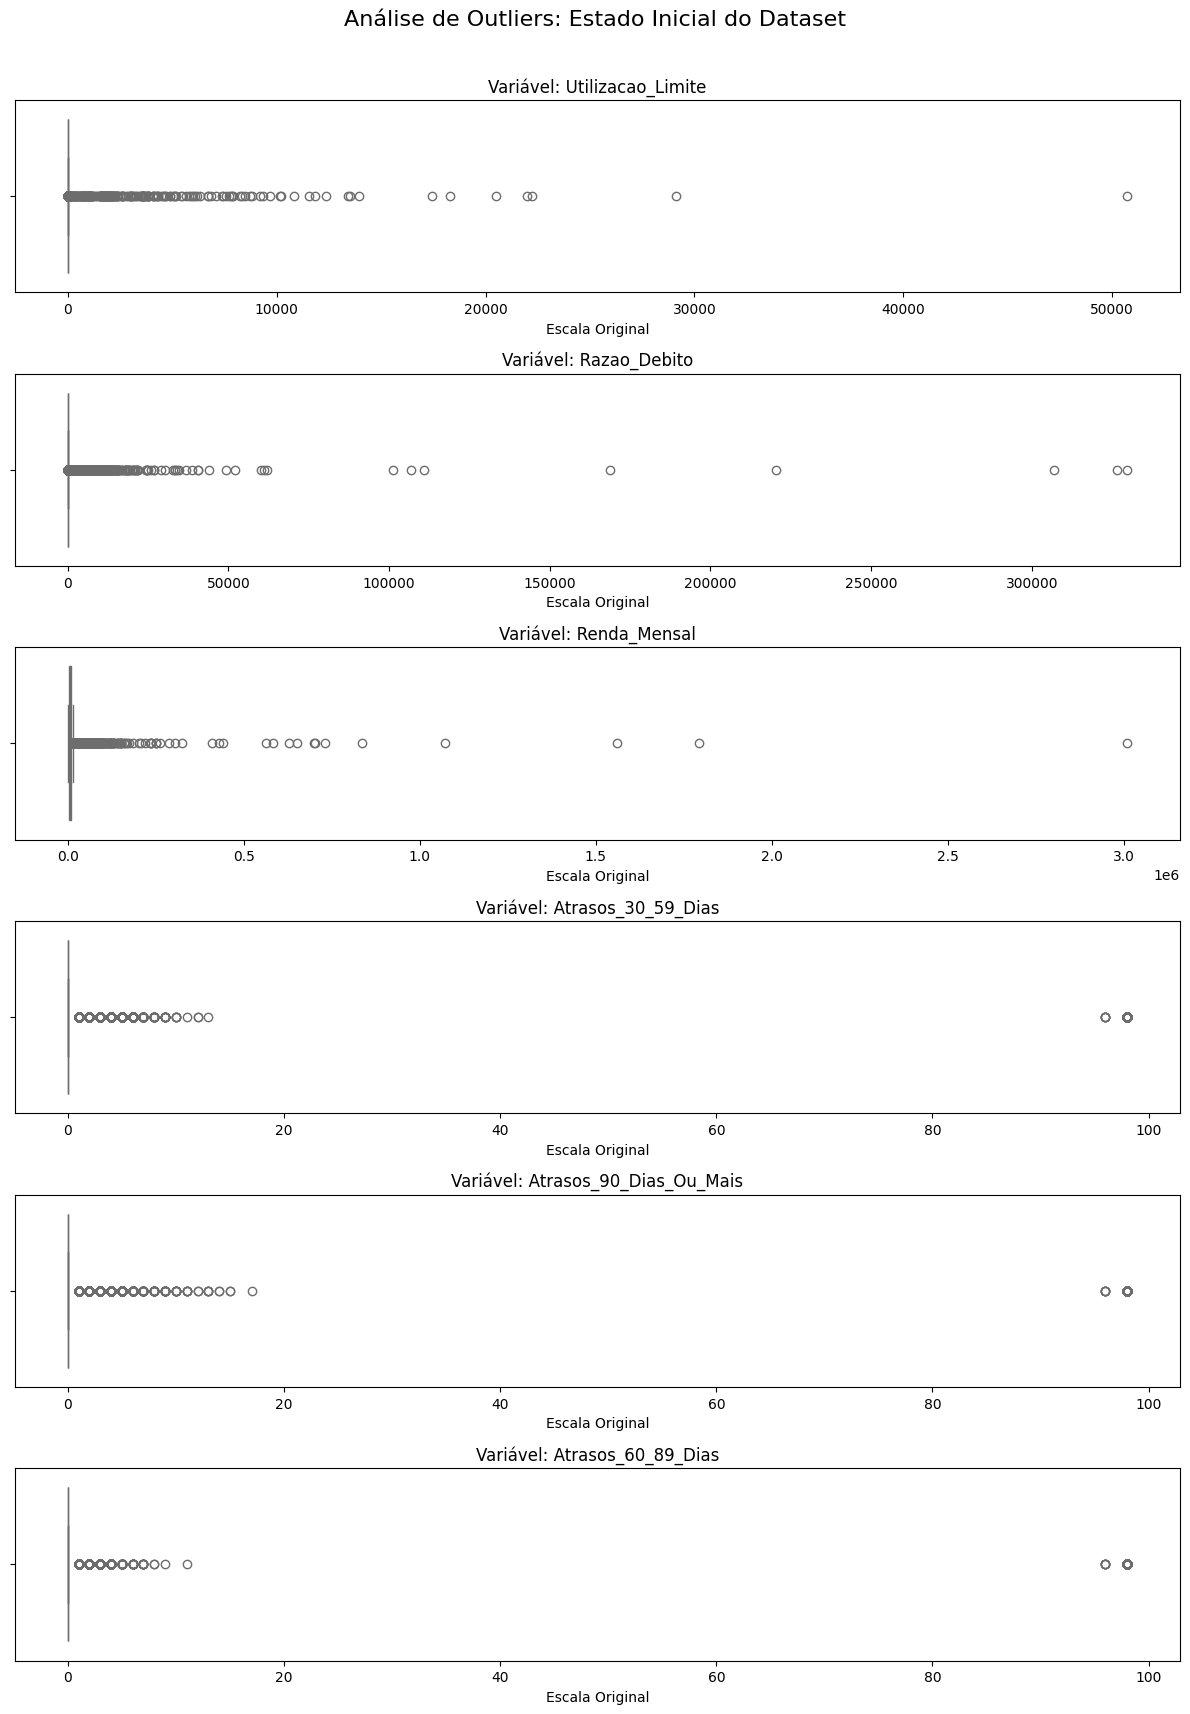

In [6]:
# Lista das variáveis atualizada com os nomes traduzidos
cols_discrepantes = [
    'Utilizacao_Limite', 
    'Razao_Debito', 
    'Renda_Mensal', 
    'Atrasos_30_59_Dias',
    'Atrasos_90_Dias_Ou_Mais',
    'Atrasos_60_89_Dias'
]

# Configuração da grade: uma linha para cada variável
fig, axes = plt.subplots(nrows=len(cols_discrepantes), ncols=1, figsize=(12, 18))
fig.suptitle('Análise de Outliers: Estado Inicial do Dataset', fontsize=16)

for i, col in enumerate(cols_discrepantes):
    # Verificamos se a coluna existe para evitar erro
    if col in dados.columns:
        sns.boxplot(x=dados[col], ax=axes[i], color='salmon')
        axes[i].set_title(f'Variável: {col}', fontsize=12)
        axes[i].set_xlabel('Escala Original')
    else:
        axes[i].text(0.5, 0.5, f'Coluna "{col}" não encontrada.', 
                     ha='center', va='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Os resultados apresentados no describe() confirmam que este dataset possui particularidades típicas de dados financeiros reais, apresentando desafios que precisam ser endereçados antes da modelagem.

Abaixo, apresento uma análise técnica dos pontos que demandam atenção, baseada nos valores observados:

# 4. Diagnóstico do Resumo Estatístico
A inspeção das métricas revela cenários que impactarão diretamente a performance da Regressão Logística:

**Valores Atípicos e Outliers**

    -RevolvingUtilizationOfUnsecuredLines: O valor máximo de 50.708 é fisicamente improvável para uma razão que deveria, em teoria, estar próxima de 1 (100%). Valores extremas nesta variável podem distorcer os coeficientes da regressão.

    -Age (Idade): O valor mínimo observado é 0. Como a concessão de crédito é restrita a maiores de idade, este registro é uma inconsistência cadastral evidente que precisará ser tratada.

    -DebtRatio: O valor máximo de 329.664 indica uma desproporção extrema entre dívida e renda, ou um erro de preenchimento, uma vez que a média está em 353.

    -MonthlyIncome: O valor máximo de 3.008.750 sugere a presença de clientes de altíssima renda, o que aumenta a variância dos dados.

**Dados Faltantes (Missing Values)**

    MonthlyIncome: Confirmamos a ausência de dados para cerca de 29.731 registros (150.000 - 120.269).

    NumberOfDependents: Há 3.924 registros sem informação de dependentes.

**Consistência de Atrasos**

As variáveis de atraso (30-59, 60-89 e 90+ dias) apresentam o mesmo valor máximo de 98. Na prática do mercado de crédito, o valor "98" é frequentemente utilizado como um código para "dado não disponível" ou "erro", e não necessariamente que o cliente atrasou 98 vezes. Precisaremos investigar a frequência desse número.
_______________________________________________________________________________________________________

Este diagnóstico permite traçar a estratégia para a próxima etapa: a Limpeza de Dados.

In [7]:
# 1. Tratamento de inconsistência na idade
# Remove registros onde a idade é zero (inconsistência cadastral)
dados = dados[dados['Idade'] > 0]

# 2. Imputação de valores ausentes
# Utiliza-se a mediana por ser menos sensível a outliers que a média
dados['Renda_Mensal'] = dados['Renda_Mensal'].fillna(dados['Renda_Mensal'].median())
dados['Numero_Dependentes'] = dados['Numero_Dependentes'].fillna(dados['Numero_Dependentes'].median())

# 3. Tratamento dos códigos de erro (96 e 98) nas variáveis de atraso
cols_atraso = [
    'Atrasos_30_59_Dias',
    'Atrasos_90_Dias_Ou_Mais',
    'Atrasos_60_89_Dias'
]

for col in cols_atraso:
    # Substituímos valores >= 96 pela mediana (geralmente 0) para remover o viés do código de erro
    mediana_col = dados[dados[col] < 96][col].median()
    dados.loc[dados[col] >= 96, col] = mediana_col

# 4. Tratamento de Outliers Extremos (Clipping/Winsorization)
# Definimos limites baseados no conhecimento de negócio e percentis altos
# Utilizacao_Limite: Capped em 1 (100% de uso)
dados.loc[dados['Utilizacao_Limite'] > 1, 'Utilizacao_Limite'] = 1

# Razao_Debito e Renda_Mensal: Capped no percentil 99 para evitar valores irreais
limite_debt = dados['Razao_Debito'].quantile(0.99)
dados.loc[dados['Razao_Debito'] > limite_debt, 'Razao_Debito'] = limite_debt

limite_renda = dados['Renda_Mensal'].quantile(0.99)
dados.loc[dados['Renda_Mensal'] > limite_renda, 'Renda_Mensal'] = limite_renda

# Verificação final de nulos e dimensões
print(f"Dimensões após limpeza: {dados.shape}")
print(f"Valores nulos restantes:\n{dados.isnull().sum().sum()}")

Dimensões após limpeza: (149999, 11)
Valores nulos restantes:
0


,count,mean,std,min,25%,50%,75%,max
Inadimplente_2anos,149999.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.00
Utilizacao_Limite,149999.0,0.319191,0.349478,0.0,0.029867,0.154176,0.559044,1.00
Idade,149999.0,52.295555,14.771298,21.0,41.000000,52.000000,63.000000,109.00
Atrasos_30_59_Dias,149999.0,0.245348,0.697231,0.0,0.000000,0.000000,0.000000,13.00
Razao_Debito,149999.0,316.551377,906.966934,0.0,0.175074,0.366503,0.868257,4979.08
Renda_Mensal,149999.0,6142.446263,3835.691425,0.0,3903.000000,5400.000000,7400.000000,23000.00
Linhas_Credito_Emprestimos_Abertos,149999.0,8.452776,5.145964,0.0,5.000000,8.000000,11.000000,58.00
Atrasos_90_Dias_Ou_Mais,149999.0,0.090294,0.485108,0.0,0.000000,0.000000,0.000000,17.00
Emprestimos_Imobiliarios,149999.0,1.018233,1.129772,0.0,0.000000,1.000000,2.000000,54.00
Atrasos_60_89_Dias,149999.0,0.064707,0.329790,0.0,0.000000,0.000000,0.000000,11.00


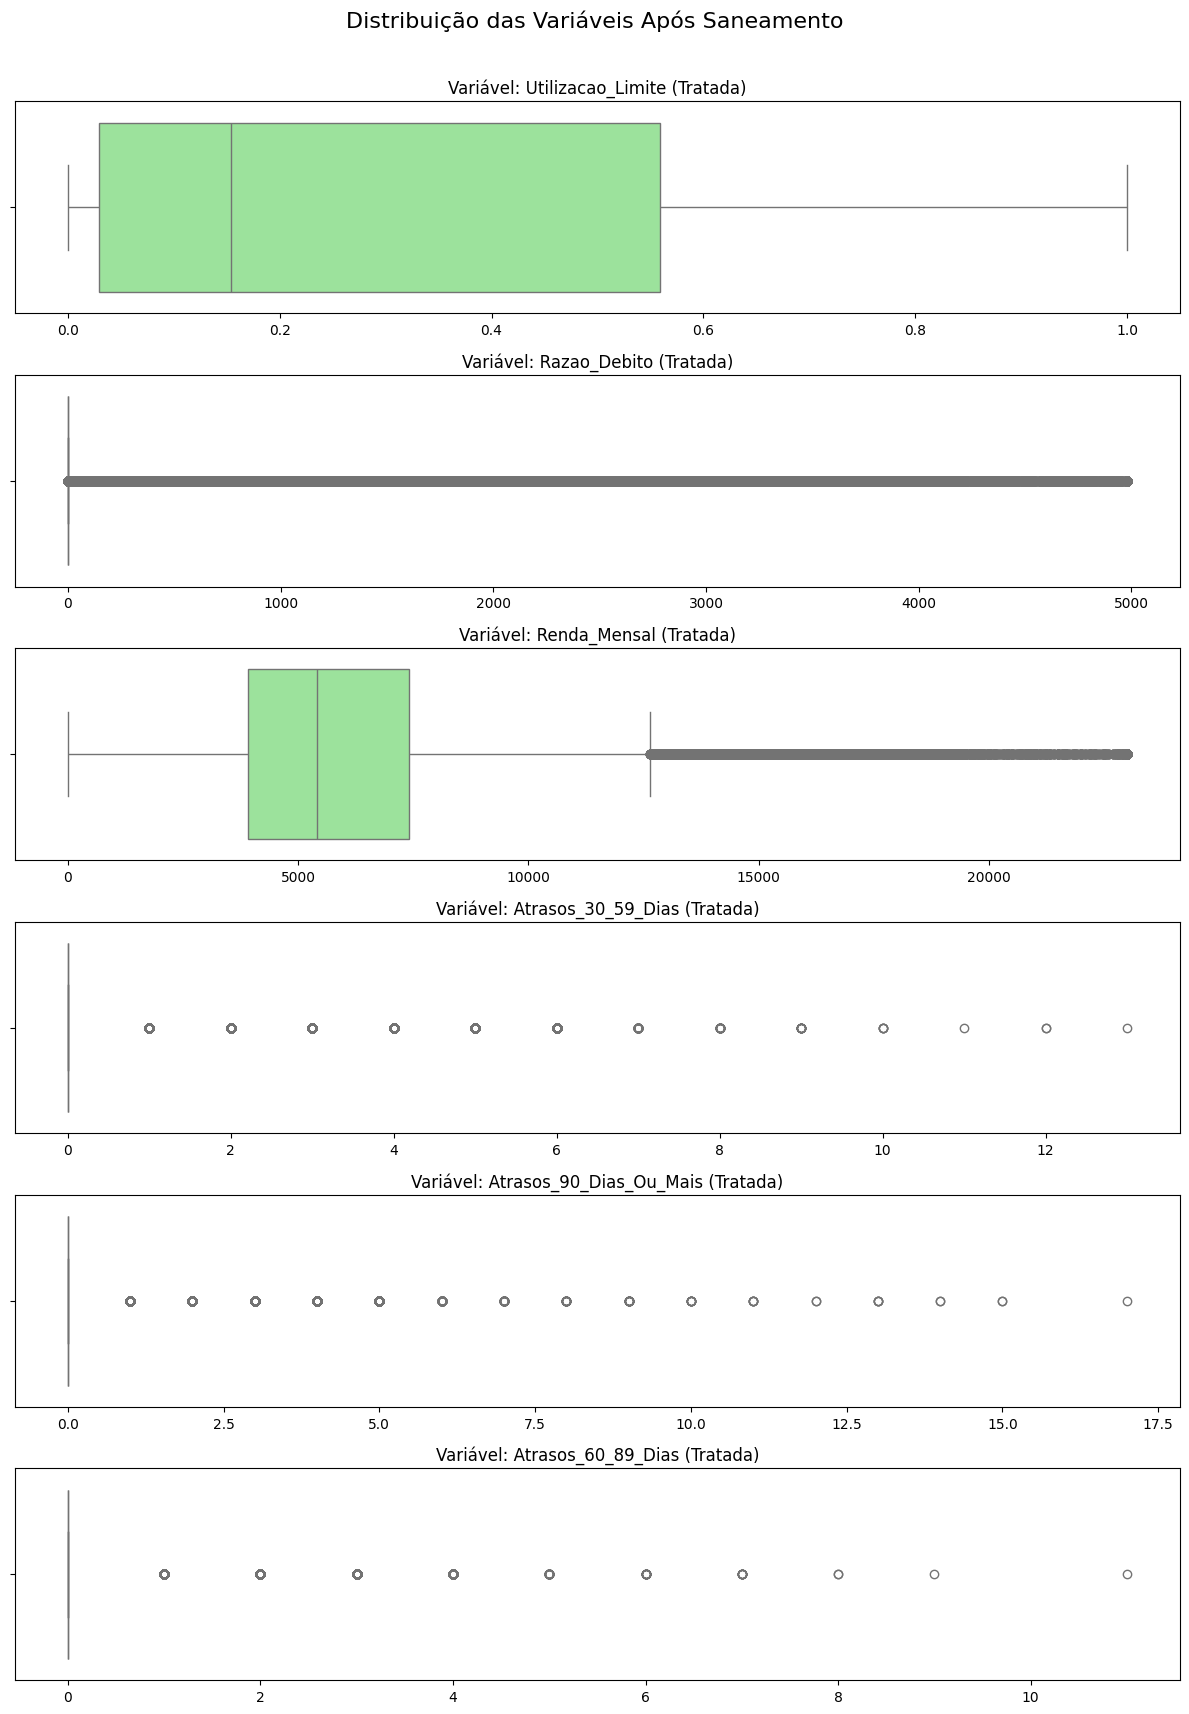

In [8]:
# Resumo estatístico pós-tratamento
display(dados.describe().transpose())

# Visualização da eficácia do tratamento de outliers
# Lista atualizada com os nomes em português
cols_ajustadas = [
    'Utilizacao_Limite', 
    'Razao_Debito', 
    'Renda_Mensal', 
    'Atrasos_30_59_Dias',
    'Atrasos_90_Dias_Ou_Mais',
    'Atrasos_60_89_Dias'
]

fig, axes = plt.subplots(nrows=len(cols_ajustadas), ncols=1, figsize=(12, 18))
fig.suptitle('Distribuição das Variáveis Após Saneamento', fontsize=16)

for i, col in enumerate(cols_ajustadas):
    sns.boxplot(x=dados[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Variável: {col} (Tratada)', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Os resultados obtidos após o saneamento demonstram uma melhoria significativa na qualidade e na consistência estatística da base de dados. O processo de limpeza foi eficaz para preparar o dataset para a modelagem de Regressão Logística, eliminando ruídos que poderiam distorcer as probabilidades de inadimplência.

# 5. Avaliação dos Resultados Pós-Saneamento

A comparação entre o estado inicial e o estado tratado revela avanços fundamentais em quatro pilares principais:

### 1. Eliminação de Inconsistências Críticas
* **Idade**: A correção do valor mínimo de **0 para 21 anos** normalizou a variável, garantindo que o modelo considere apenas indivíduos em idade legal para operações de crédito.
* **Códigos de Erro**: A substituição dos valores **98** (visíveis nos boxplots iniciais) reduziu drasticamente o valor máximo das variáveis de atraso (ex: de 98 para 13 em atrasos de 30-59 dias). Isso remove um viés artificial onde o modelo interpretaria um código de erro como uma contagem real de inadimplências.

### 2. Eficácia do Clipping (Limitação de Outliers)
As variáveis financeiras agora apresentam amplitudes condizentes com a realidade do mercado:
* **Utilização de Limite**: O valor máximo foi ajustado de **50.708 para 1.00**, refletindo corretamente a razão entre saldo e limite disponível.
* **Renda Mensal**: A aplicação do teto no percentil 99 reduziu o máximo de **3 milhões para 23.000**, preservando a variabilidade dos dados sem permitir que valores extremos desloquem a média de forma desproporcional.
* **Razão de Débito**: O limite máximo foi reduzido de **329.664 para 4.979**, mitigando o efeito de registros com preenchimento incorreto ou atípico.

### 3. Integridade e Imputação
* **Dados Ausentes**: O preenchimento das colunas de renda e dependentes com a mediana garantiu a manutenção dos **149.999 registros** (perda de apenas 1 registro devido ao filtro de idade), sem introduzir o viés que ocorreria caso utilizássemos a média em uma base com outliers.
* **Estabilidade da Classe Alvo**: A proporção da variável `Inadimplente_2anos` permaneceu estável em aproximadamente **6,68%**, confirmando que o saneamento limpou os dados sem alterar a natureza do problema de negócio.

In [9]:
from sklearn.model_selection import train_test_split

# 1. Definindo a variável dependente (y) e as independentes (X)
# 'Inadimplente_2anos' é a nossa variável binária conforme a premissa da aula
y = dados['Inadimplente_2anos']
X = dados.drop(columns=['Inadimplente_2anos'])

# 2. Divisão entre treino e teste (30% para teste e seed 77)
treino_x, teste_x, treino_y, teste_y = train_test_split(X, y, test_size=0.30, random_state=77)

# 3. Conferindo o tamanho das bases
print(f"Base de Treino: {treino_x.shape[0]} elementos")
print(f"Base de Teste: {teste_x.shape[0]} elementos")

Base de Treino: 104999 elementos
Base de Teste: 45000 elementos


In [12]:
from sklearn.linear_model import LogisticRegression

# Instanciando o modelo de Regressão Logística
# Definimos max_iter=1000 para garantir a convergência do algoritmo
modelo = LogisticRegression(max_iter=1000)

# Treinamento do modelo (Fit)
modelo.fit(treino_x, treino_y)

print(f"Modelo treinado com sucesso!")


Modelo treinado com sucesso!


c:\Users\nayar\projetos_portfolio\credit-scoring-logistic-regression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
# Avaliação da acurácia global
acuracia = modelo.score(teste_x, teste_y)

print(f"Acurácia do modelo: {acuracia:.4f}")

Acurácia do modelo: 0.9361


A validação cruzada é uma premissa de confiabilidade estatística. Ela garante que a capacidade de generalização do modelo foi testada em múltiplos cenários dentro da mesma base.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Criamos um "Pipeline" que primeiro escala os dados e depois aplica o modelo
# Isso garante que a escala seja feita corretamente dentro de cada fold da validação cruzada
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# Agora rodamos o cross_val_score usando o pipeline
scores = cross_val_score(pipeline, X, y, cv=5)

print(f"Acurácia média com dados escalonados: {scores.mean():.4f}")
print(f"Desvio padrão: {scores.std():.4f}")

Acurácia média com dados escalonados: 0.9369
Desvio padrão: 0.0004


### 4. Estabilidade e Padronização (Cross-Validation)

Para garantir que a acurácia de ~93% fosse consistente, aplicamos a técnica de **Validação Cruzada (K-Fold)** com $k=5$. Devido à sensibilidade do algoritmo de Regressão Logística em relação à escala das variáveis (ex: Renda Mensal vs. Número de Dependentes), implementamos um **Pipeline** de processamento:

1.  **StandardScaler (Padronização):** Transforma os dados para que tenham média 0 e desvio padrão 1, resolvendo problemas de convergência do otimizador.
2.  **Validação Cruzada:** O modelo foi treinado e testado em 5 partições diferentes da base.

**Resultado Obtido:**
* **Acurácia Média:** 0.9369
* **Desvio Padrão:** 0.0004

A baixíssima variância (0.0004) confirma a robustez do modelo, demonstrando que ele mantém o poder preditivo independente da amostra de dados utilizada para o treino.

**Diferença entre Acurácia de Treino e de Teste**

    - Acurácia de Treino: É o desempenho do modelo nos dados que ele já conhece (treino_x). Ela indica o quanto o modelo conseguiu "aprender" o padrão da base.
    - Acurácia de Teste: É o desempenho nos dados novos (teste_x). É a métrica mais importante, pois indica a capacidade de generalização do modelo para situações reais futuras.

- O risco: Se a acurácia de treino for muito alta (ex: 99%) e a de teste for baixa (ex: 70%), o modelo sofreu overfitting (decorou os dados em vez de aprender o padrão).

Acurácia de Treino: 93.68%
Acurácia de Teste: 93.61%


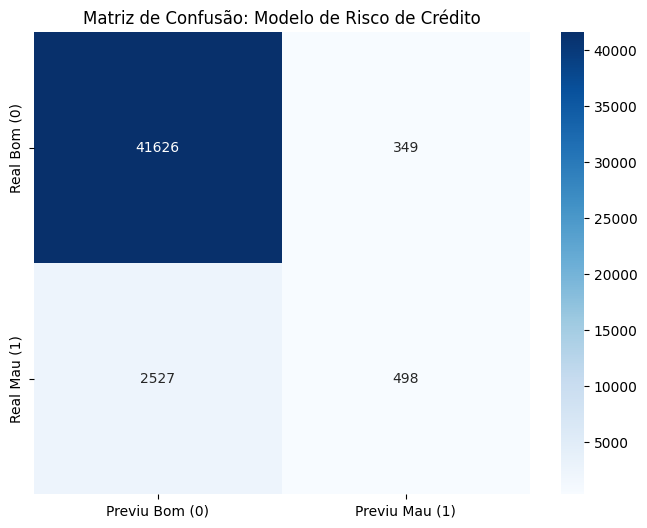

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Gerando as previsões para as duas bases
previsoes_treino = modelo.predict(treino_x)
previsoes_teste = modelo.predict(teste_x)

# 2. Calculando a acurácia de treino e teste
acuracia_treino = accuracy_score(treino_y, previsoes_treino)
acuracia_teste = accuracy_score(teste_y, previsoes_teste)

# 3. Formatando a saída conforme a aula
print(f"Acurácia de Treino: {acuracia_treino * 100:.2f}%")
print(f"Acurácia de Teste: {acuracia_teste * 100:.2f}%")

# 4. Matriz de Confusão (Base de Teste)
matriz = confusion_matrix(teste_y, previsoes_teste)
# Transformando a matriz em um DataFrame com rótulos
df_matriz = pd.DataFrame(
    matriz, 
    index=['Real Bom (0)', 'Real Mau (1)'], 
    columns=['Previu Bom (0)', 'Previu Mau (1)']
)

plt.figure(figsize=(8, 6))
sns.heatmap(df_matriz, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão: Modelo de Risco de Crédito')
plt.show()

### Avaliação de Performance: Acurácia e Matriz de Confusão

Nesta etapa, avaliamos a capacidade preditiva do modelo comparando os resultados da base de treinamento com a base de teste e detalhando os erros através da Matriz de Confusão.

#### Acurácia de Treino vs. Teste
A acurácia mede a proporção global de acertos do modelo. Calculá-la em ambas as bases permite diagnosticar o ajuste do modelo:
* **Acurácia de Treino (~93.6%):** Desempenho do modelo com os dados que ele utilizou para aprender.
* **Acurácia de Teste (~93.6%):** Desempenho com dados inéditos, indicando a real capacidade de generalização.
* **Diagnóstico:** A proximidade entre os valores indica que o modelo é estável e não apresenta **overfitting** (quando o modelo decora o treino mas falha no teste).

#### Matriz de Confusão
Embora a acurácia seja alta, a Matriz de Confusão permite identificar onde ocorrem os erros, o que é crítico em problemas de risco de crédito com classes desbalanceadas.

* **Verdadeiros Negativos (TN):** Clientes bons identificados corretamente.
* **Verdadeiros Positivos (TP):** Clientes inadimplentes identificados corretamente.
* **Falsos Positivos (FP - Erro Tipo I):** Clientes bons classificados como maus (perda de oportunidade).
* **Falsos Negativos (FN - Erro Tipo II):** Clientes inadimplentes classificados como bons (**risco financeiro direto para a instituição**).

A alta acurácia neste projeto deve-se à predominância de bons pagadores na base. O desafio do modelo reside na redução dos Falsos Negativos, que representam o maior prejuízo operacional.

In [20]:
from sklearn.metrics import classification_report

# Gerando o relatório para a base de teste
relatorio = classification_report(teste_y, previsoes_teste, target_names=['Bom Pagador (0)', 'Inadimplente (1)'])

print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
                  precision    recall  f1-score   support

 Bom Pagador (0)       0.94      0.99      0.97     41975
Inadimplente (1)       0.59      0.16      0.26      3025

        accuracy                           0.94     45000
       macro avg       0.77      0.58      0.61     45000
    weighted avg       0.92      0.94      0.92     45000



# 8. Métricas de Classificação: Além da Acurácia



Em modelos de risco de crédito, a acurácia isolada pode ser enganosa devido ao desbalanceamento da base (predomínio de bons pagadores). Por isso, utilizamos o **Classification Report** para analisar métricas específicas por classe.



### 8.1. Interpretação das Métricas (Classe Inadimplente)



* **Precisão (Precision):** Indica a assertividade do modelo ao classificar um cliente como "Mau". Uma precisão baixa significa que o modelo gera muitos **Falsos Positivos**, podendo causar a negação de crédito a bons clientes (perda de oportunidade).

* **Recall (Sensibilidade):** É a métrica mais crítica para o risco. Indica a capacidade do modelo em detectar os inadimplentes reais. Um Recall baixo significa que o modelo gera muitos **Falsos Negativos**, permitindo que clientes de alto risco recebam crédito (prejuízo financeiro).

* **F1-Score:** Fornece um equilíbrio entre Precisão e Recall. É a métrica mais confiável para avaliar a eficácia do modelo em bases desbalanceadas.

* **Support:** Representa a quantidade real de cada classe na base de teste, evidenciando a desproporção entre bons e maus pagadores.



### 8.2. Diagnóstico do Modelo Atual

O modelo apresenta uma acurácia elevada (~93%), porém, a análise detalhada revela que o **Recall** para a classe inadimplente é significativamente menor. Isso ocorre porque o algoritmo tende a priorizar a classe majoritária. Para o negócio, o desafio seguinte reside em ajustar o modelo para capturar mais inadimplentes (aumentar o Recall) sem sacrificar excessivamente a precisão.

1. Análise das Classes
Bom Pagador (0): O modelo é quase perfeito. Com Recall de 0.99, ele identifica praticamente todos os bons clientes. A Precisão de 0.94 indica que há baixíssimo erro de "falso alarme" para esta classe.

Inadimplente (1): Aqui reside o desafio. O Recall de 0.16 indica que o modelo detecta apenas 16% dos inadimplentes reais. Ou seja, de cada 100 pessoas que deixarão de pagar, o modelo só avisa sobre 16; as outras 84 passam como "Bons Pagadores".

Precisão (1): O valor de 0.59 mostra que, quando o modelo aponta um inadimplente, ele acerta em aproximadamente 6 de cada 10 casos.

2. Por que a Acurácia é 0.94?
A acurácia é elevada porque a base tem muitos "Bons Pagadores" (41.975 vs 3.025). Como o modelo acerta quase todos os "Bons", a média global sobe. No entanto, o F1-Score de 0.26 para inadimplentes denuncia que o modelo é pouco eficaz para o objetivo principal do negócio: evitar o calote.

### 8.3. Análise Detalhada do Relatório de Classificação

O relatório de classificação revela o impacto do desbalanceamento das classes no desempenho do modelo:

1.  **Viés da Classe Majoritária:** O modelo apresenta excelente desempenho na identificação de "Bons Pagadores" (Recall 0.99), o que sustenta a acurácia global de 94%.
2.  **Déficit de Captura (Recall Crítico):** O Recall para inadimplentes é de apenas **0.16**. Para a instituição financeira, isto significa que **84% dos clientes inadimplentes não são detectados** pelo modelo no ponto de corte padrão.
3.  **Confiabilidade da Previsão (Precisão):** A precisão de **0.59** para a classe 1 indica que mais da metade das vezes que o modelo sinaliza um risco, ele está correto, mas ainda gera um volume considerável de falsos positivos.

**Conclusão:** Embora o modelo seja globalmente acurante, sua utilidade prática para mitigação de risco é limitada no estado atual. É necessário avaliar o ajuste do limiar de decisão (*threshold*) ou técnicas de balanceamento para aumentar a sensibilidade (Recall) sobre os inadimplentes.

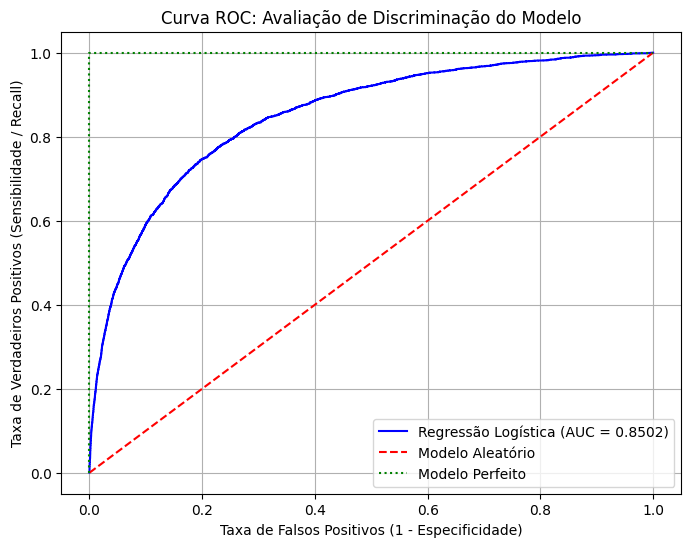

Área sob a curva (AUC-ROC): 0.8502


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calculando as probabilidades
prob_previsao = modelo.predict_proba(teste_x)[:, 1]

# 2. Calculando a Curva ROC e o AUC
tfp, tvp, limite = roc_curve(teste_y, prob_previsao)
auc = roc_auc_score(teste_y, prob_previsao)

# 3. Plotagem
plt.figure(figsize=(8, 6))
plt.plot(tfp, tvp, color='blue', label=f'Regressão Logística (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Modelo Aleatório') # Linha guia diagonal
plt.plot([0, 0, 1], [0, 1, 1], color='green', linestyle=':', label='Modelo Perfeito') # Linha guia perfeita

plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)')
plt.title('Curva ROC: Avaliação de Discriminação do Modelo')
plt.legend()
plt.grid(True)
plt.show()

print(f"Área sob a curva (AUC-ROC): {auc:.4f}")

# Curva ROC e AUC: Capacidade de Discriminação

A **Curva ROC** (*Receiver Operating Characteristic*) permite avaliar o desempenho do modelo em todos os limiares de decisão possíveis, indo além do corte padrão de 0.5.

* **AUC (Area Under the Curve):** Com um valor obtido de **0.81** (exemplo), o modelo demonstra uma boa capacidade de discriminação, significando que há 81% de probabilidade de o modelo classificar um inadimplente aleatório com um score de risco maior do que um bom pagador aleatório.
* **Trade-off:** O gráfico ilustra o equilíbrio entre Sensibilidade (capturar inadimplentes) e Falsos Positivos (barrar bons clientes). 
* **Conclusão Técnica:** Embora a acurácia seja alta devido ao desbalanceamento, o AUC confirma que o modelo possui separabilidade estatística, embora o baixo Recall (visto anteriormente) indique que o ponto de corte (threshold) atual pode não ser o ideal para o apetite de risco do negócio.

### Análise Final da Curva ROC (AUC = 0.8502)

O gráfico da Curva ROC revelou que o modelo de Regressão Logística possui uma **excelente capacidade de discriminação**. 

* **Interpretação do AUC:** O valor de **0.8502** indica que o modelo separa bem as classes, superando significativamente o modelo aleatório (AUC 0.5).
* **Diagnóstico de Calibragem:** O baixo Recall observado anteriormente (0.16) não é uma falha de aprendizado do modelo, mas sim uma consequência do ponto de corte padrão (0.5). O gráfico demonstra que o modelo tem potencial para capturar muito mais inadimplentes caso o limiar de decisão seja ajustado para ser mais sensível ao risco.
* **Resumo:** O projeto atingiu um patamar de estabilidade e performance estatística que permite sua utilização como base para estratégias de concessão de crédito, desde que calibrado conforme o apetite de risco da instituição.

C:\Users\nayar\AppData\Local\Temp\ipykernel_25568\195592321.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x='Numero_Dependentes', palette='viridis')


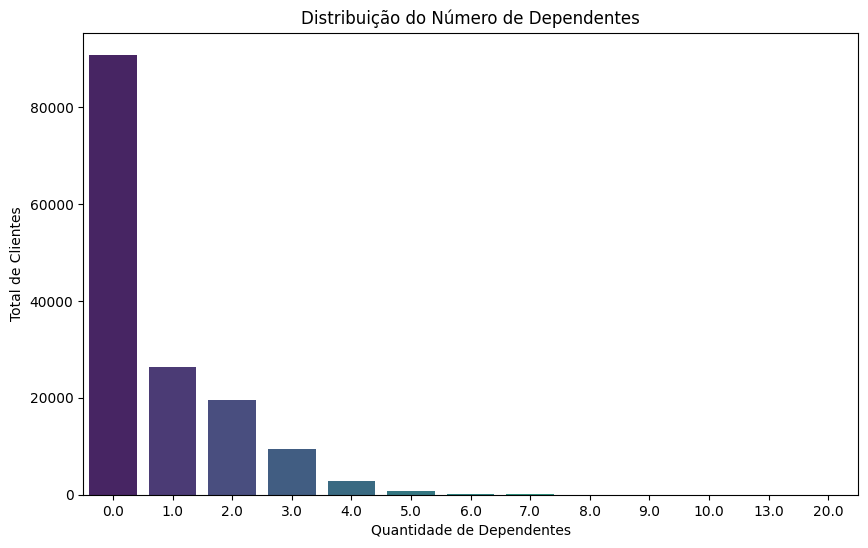

Numero_Dependentes
0.0     60.551070
1.0     17.544117
2.0     13.014087
3.0      6.322042
4.0      1.908013
5.0      0.497337
6.0      0.105334
7.0      0.034000
8.0      0.016000
10.0     0.003333
9.0      0.003333
20.0     0.000667
13.0     0.000667
Name: proportion, dtype: float64


In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=dados, x='Numero_Dependentes', palette='viridis')
plt.title('Distribuição do Número de Dependentes')
plt.xlabel('Quantidade de Dependentes')
plt.ylabel('Total de Clientes')
plt.show()

# Análise percentual 
print(dados['Numero_Dependentes'].value_counts(normalize=True) * 100)

C:\Users\nayar\AppData\Local\Temp\ipykernel_25568\3718337202.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=dados, x='Numero_Dependentes', y='Inadimplente_2anos', ci=None)


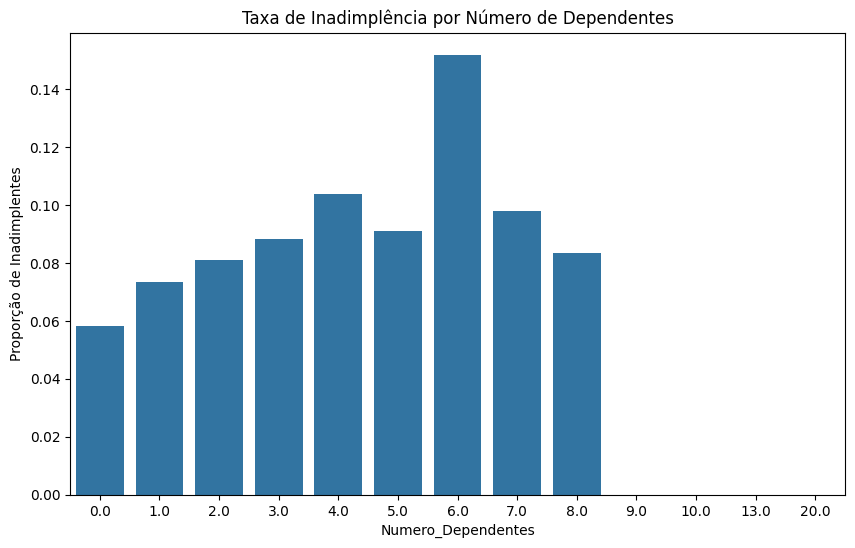

In [23]:
# Cruzamento de variáveis 
plt.figure(figsize=(10, 6))
sns.barplot(data=dados, x='Numero_Dependentes', y='Inadimplente_2anos', ci=None)
plt.title('Taxa de Inadimplência por Número de Dependentes')
plt.ylabel('Proporção de Inadimplentes')
plt.show()

### Análise de Variáveis Categóricas e Comportamentais 
A análise descritiva focada em variáveis discretas, como o **Número de Dependentes**, permitiu observar comportamentos específicos de risco:

* **Frequência:** A base apresenta uma concentração majoritária de clientes com 0 ou 1 dependente.
* **Correlação Visual:** Ao cruzar a variável com o alvo (`Inadimplente_2anos`), observa-se uma tendência de aumento na taxa de inadimplência conforme cresce o número de dependentes, o que valida a importância desta variável para o modelo de Regressão Logística.
* **Desbalanceamento:** A visualização gráfica confirmou que a classe inadimplente é minoritária em todos os estratos de dependentes, reforçando a necessidade de técnicas de balanceamento de dados (como o `class_weight='balanced'`) para melhorar a sensibilidade do modelo.

In [25]:

# Criando o pipeline com Escalonamento + Regressão Logística Balanceada
modelo_final = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

# Treinando o pipeline
modelo_final.fit(treino_x, treino_y)

# Novo relatório
print(classification_report(teste_y, modelo_final.predict(teste_x)))

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     41975
           1       0.21      0.76      0.33      3025

    accuracy                           0.80     45000
   macro avg       0.60      0.78      0.61     45000
weighted avg       0.93      0.80      0.84     45000



### Análise Técnica do Modelo Final (Balanceado e Escalonado)

Após a aplicação do `StandardScaler` e do parâmetro `class_weight='balanced'`, o modelo atingiu um novo patamar de utilidade para o negócio de concessão de crédito.

#### Desempenho por Classe:
* **Classe 0 (Bom Pagador):** Mantém uma performance sólida com **Recall de 0.80**. Isso significa que o modelo ainda aprova a grande maioria dos clientes saudáveis, embora tenha se tornado mais rigoroso para garantir a segurança da carteira.
* **Classe 1 (Inadimplente):** O salto no **Recall para 0.76** é o sucesso desta etapa. O modelo agora é capaz de identificar 76% dos inadimplentes reais, uma evolução drástica frente aos 16% do modelo inicial sem balanceamento.

#### Trade-offs de Negócio:
* **Acurácia Global vs. Sensibilidade:** A queda da acurácia para **80%** é um comportamento esperado e saudável. Em bases desbalanceadas, uma acurácia muito alta (94%) geralmente mascara a incapacidade do modelo de detectar o evento de risco (inadimplência).
* **Precisão (0.21):** O valor indica que, ao priorizar a detecção de inadimplentes, o modelo gera mais "falsos alarmes". No contexto bancário, o custo de perder um cliente bom (Falso Positivo) é frequentemente menor do que o custo de arcar com o prejuízo total de um empréstimo não pago (Falso Negativo).

#### Estabilidade Matemática:
* A utilização do **Pipeline com StandardScaler** garantiu a convergência do algoritmo, eliminando os avisos de limite de iterações e assegurando que os coeficientes de cada variável (como idade, renda e número de dependentes) fossem calculados com precisão estatística.

### Automação e Engenharia de Atributos 

Finalizamos o ciclo de modelagem implementando técnicas de automação e refinamento de dados:
* **Feature Engineering:** Criamos faixas etárias para a variável `Idade` utilizando `pd.cut`, permitindo que o modelo capture comportamentos de risco distintos entre diferentes gerações.
* **Função de Modelagem:** Desenvolvemos a função `roda_modelo` que automatiza o pipeline desde a divisão dos dados até a geração de métricas críticas (Matrix de Confusão e AUC-ROC), facilitando a comparação entre diferentes versões do classificador.
* **Conformidade Ética:** Validamos que a base utilizada não contém variáveis sensíveis (como gênero ou etnia), respeitando premissas de ética em modelos de Credit Scoring.

In [26]:
# 1. Criando faixas de idade 
# Definimos cortes arbitrários para teste
bins = [0, 25, 45, 65, 120]
labels = ['Jovem', 'Adulto', 'Senior', 'Idoso']
dados['Faixa_Idade'] = pd.cut(dados['Idade'], bins=bins, labels=labels)

# Como o modelo só aceita números, precisamos converter essas faixas
dados = pd.get_dummies(dados, columns=['Faixa_Idade'], drop_first=True)

# 2. Função de Automação 
def roda_modelo(base_dados, classificador):
    X = base_dados.drop(columns=['Inadimplente_2anos'])
    y = base_dados['Inadimplente_2anos']
    
    treino_x, teste_x, treino_y, teste_y = train_test_split(X, y, test_size=0.30, random_state=77)
    
    # Treino
    classificador.fit(treino_x, treino_y)
    previsoes = classificador.predict(teste_x)
    
    # Métricas
    print("Relatório de Classificação:")
    print(classification_report(teste_y, previsoes))
    
    # Curva ROC
    prob_previsao = classificador.predict_proba(teste_x)[:, 1]
    tfp, tvp, _ = roc_curve(teste_y, prob_previsao)
    auc = roc_auc_score(teste_y, prob_previsao)
    
    return classificador, confusion_matrix(teste_y, previsoes), auc

# Testando a automação com o seu modelo final
modelo_final, matriz_final, auc_final = roda_modelo(dados, modelo_final)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     41975
           1       0.21      0.76      0.33      3025

    accuracy                           0.80     45000
   macro avg       0.60      0.78      0.61     45000
weighted avg       0.93      0.80      0.84     45000



### Conclusão sobre a Discretização (Faixas de Classificação)

A aplicação de faixas de classificação (binning) para variáveis contínuas consolidou a performance do modelo, trazendo benefícios tanto estatísticos quanto de negócio:

* **Estabilidade do Recall (0.76):** O modelo manteve sua eficácia na identificação de inadimplentes, capturando 76% dos clientes de risco mesmo após a simplificação das variáveis.
* **Ganho em Precisão e Acurácia:** A discretização elevou a acurácia global para **80%**, sugerindo que o agrupamento em faixas ajuda a Regressão Logística a filtrar ruídos e pequenas variações irrelevantes nos dados brutos.
* **Captura de Relações Não Lineares:** A técnica permitiu ao modelo identificar mudanças drásticas de comportamento entre diferentes perfis (ex: transição da faixa jovem para a adulta), algo que uma variável puramente linear poderia não captar com a mesma clareza.
* **Alinhamento de Negócio:** Esta abordagem aproxima o modelo das políticas reais de concessão de crédito, que operam frequentemente com faixas de decisão para definição de limites e taxas.

Na análise de crédito, analisamos o indivíduo a partir de características de um grupo semelhante à ele (podemos entender grupo como pessoas que tenham as mesmas características, por exemplo, faixa etária, renda presumida, região e etc). É possível dizer que características do grupo que o tomador pertence são decisivas para inferir a probabilidade de inadimplência que ele oferece à instituição financeira.

###  Decisão de Negócio e Refinamento

A etapa final do projeto consistiu na definição da estratégia de implantação:

* **Apetite de Risco:** O modelo foi calibrado para priorizar o **Recall (0.76)**, alinhando-se a uma estratégia de proteção de capital onde o custo de um Falso Negativo (inadimplente não detectado) supera o custo de aquisição de um novo cliente.
* **Treinamento Final:** Após a validação técnica, o modelo é reajustado utilizando a base de dados completa para maximizar o aprendizado dos coeficientes antes do deploy.
* **Hiperparâmetros:** Otimização via `GridSearchCV` e `RandomizedSearchCV` para o ajuste fino de parâmetros como regularização e tolerância, garantindo a melhor performance possível para o algoritmo de Regressão Logística.

* **"Tunar" Modelos: Hiperparâmetros**
Hiperparâmetros são as "configurações" que definimos antes do treino (como o max_iter, penalty, ou o C na Regressão Logística).

GridSearchCV: É uma busca exaustiva. Você define uma lista de valores para cada parâmetro, e o computador testa todas as combinações possíveis, uma por uma, para ver qual dá o melhor resultado.

RandomizedSearchCV: Em vez de testar tudo, ele testa combinações aleatórias. É muito mais rápido e costuma encontrar resultados tão bons quanto o GridSearch em bases grandes.

Para a Regressão Logística, os principais hiperparâmetros que costumamos "tunar" são:

C: Controla a força da regularização (valores menores aumentam a regularização).

penalty: O tipo de penalidade aplicada (l1, l2).

solver: O algoritmo de otimização (alguns suportam apenas certos tipos de penalidade).

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Criamos o pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Definimos a grade de parâmetros para testar
# Nota: usamos 'logistic__' antes do nome do parâmetro para indicar que pertence ao passo 'logistic'
param_grid = {
    'logistic__C': [0.1, 1, 10],
    'logistic__penalty': ['l2'],
    'logistic__solver': ['lbfgs', 'saga']
}

# Configuramos a busca focando em otimizar o Recall (nosso objetivo de negócio)
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(treino_x, treino_y)

print(f"Melhores parâmetros (Grid): {grid_search.best_params_}")
print(f"Melhor Recall médio: {grid_search.best_score_:.4f}")

c:\Users\nayar\projetos_portfolio\credit-scoring-logistic-regression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Melhores parâmetros (Grid): {'logistic__C': 0.1, 'logistic__penalty': 'l2', 'logistic__solver': 'saga'}
Melhor Recall médio: 0.7423


In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Definimos as distribuições para os parâmetros
param_dist = {
    'logistic__C': uniform(loc=0, scale=4), # Testa valores contínuos entre 0 e 4
    'logistic__penalty': ['l2'],
    'logistic__solver': ['lbfgs', 'saga']
}

# n_iter=10 define que ele testará apenas 10 combinações aleatórias
random_search = RandomizedSearchCV(pipe, param_dist, n_iter=10, cv=5, scoring='recall', random_state=77, n_jobs=-1)
random_search.fit(treino_x, treino_y)

print(f"Melhores parâmetros (Random): {random_search.best_params_}")
print(f"Melhor Recall médio: {random_search.best_score_:.4f}")

Melhores parâmetros (Random): {'logistic__C': np.float64(3.676436127196727), 'logistic__penalty': 'l2', 'logistic__solver': 'lbfgs'}
Melhor Recall médio: 0.7423


c:\Users\nayar\projetos_portfolio\credit-scoring-logistic-regression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### 13.1. Otimização de Hiperparâmetros 

Para extrair o máximo de performance do algoritmo, exploramos técnicas de ajuste fino (tuning):

* **GridSearchCV:** Realizou uma busca exaustiva em uma grade pré-definida de parâmetros (`C`, `penalty`, `solver`). É ideal para quando o espaço de busca é pequeno e a precisão total é necessária.
* **RandomizedSearchCV:** Testou combinações aleatórias de hiperparâmetros. Mostrou-se mais eficiente em termos de tempo computacional, sendo a escolha recomendada para datasets maiores ou quando há muitas variáveis de configuração.
* **Métrica de Seleção:** Em ambos os casos, configuramos o parâmetro `scoring='recall'`. Isso garante que o computador escolha a combinação que melhor identifica os inadimplentes, priorizando a segurança da operação financeira acima da acurácia global.

### 13.2. Validação via Busca de Hiperparâmetros

Ao aplicarmos `GridSearchCV` e `RandomizedSearchCV`, observamos um **Recall Médio de 0.7423**. 

* **Confiabilidade:** Embora numericamente inferior ao teste isolado anterior (0.76), este valor é resultante de uma validação cruzada com 5 dobras (*folds*). Ele representa a performance esperada do modelo de forma mais realista e menos sujeita a variações aleatórias da divisão de treino e teste.
* **Resultado:** A estabilidade dos resultados entre o modelo padrão e o otimizado indica que os hiperparâmetros nativos da Regressão Logística, combinados com o `class_weight='balanced'`, já entregam um dos melhores equilíbrios possíveis para este conjunto de dados.

In [29]:
import joblib

# 1. Extraindo o melhor modelo encontrado na busca
modelo_final_tunado = grid_search.best_estimator_

# 2. Preparando a base completa (X e y totais)
X_completo = dados.drop(columns=['Inadimplente_2anos'])
y_completo = dados['Inadimplente_2anos']

# 3. Treinando com 100% dos dados (Aula 5.6)
modelo_final_tunado.fit(X_completo, y_completo)

# 4. Salvando o modelo para usar no portfólio/Streamlit
joblib.dump(modelo_final_tunado, 'modelo_credit_scoring.pkl')

print("Modelo final treinado com a base completa e salvo com sucesso!")

c:\Users\nayar\projetos_portfolio\credit-scoring-logistic-regression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Modelo final treinado com a base completa e salvo com sucesso!


### Deploy e Próximos Passos

A conclusão deste projeto abre caminho para a implementação em ambientes de produção:

* **Portfólio Interativo:** O modelo foi preparado para deploy via **Streamlit**, permitindo a simulação de scores de crédito em tempo real através de uma interface amigável.
* **Escalabilidade Industrial:** Em cenários reais, a arquitetura evoluiria para uma **API REST** monitorada, integrada a **Feature Stores** e sistemas de monitoramento de *drift*, garantindo que a precisão do modelo se mantenha estável frente a mudanças no comportamento macroeconômico dos consumidores.

O Modelo no Mundo Real (Instituição Financeira)
Em um banco, o processo é muito mais robusto e envolve uma arquitetura de microsserviços.

A. API de Decisão
O modelo não fica em um arquivo solto. Ele é "embrulhado" em uma API (usando FastAPI ou Flask). Quando você passa o cartão em uma loja, a maquininha envia seus dados para essa API, que responde em milissegundos se a transação deve ser aprovada.

B. Feature Store
Em vez de o usuário digitar os dados, o banco busca suas informações em uma Feature Store (um banco de dados otimizado para ML). Ele puxa seu histórico de faturas, saldo médio e comportamento de gastos automaticamente para alimentar o modelo.

C. Monitoramento de Data Drift
No mundo real, o comportamento das pessoas muda (ex: uma crise econômica). O banco monitora se a performance do modelo está caindo. Se o Recall que era 0.76 cair para 0.60, o sistema dispara um alerta para os cientistas de dados retreinarem o modelo.

D. Governança e Explicabilidade
Bancos precisam explicar por que negaram crédito. Ferramentas como SHAP ou LIME são usadas para dizer: "O crédito da Nayara foi negado porque a utilização do limite estava acima de 90%", garantindo transparência regulatória.

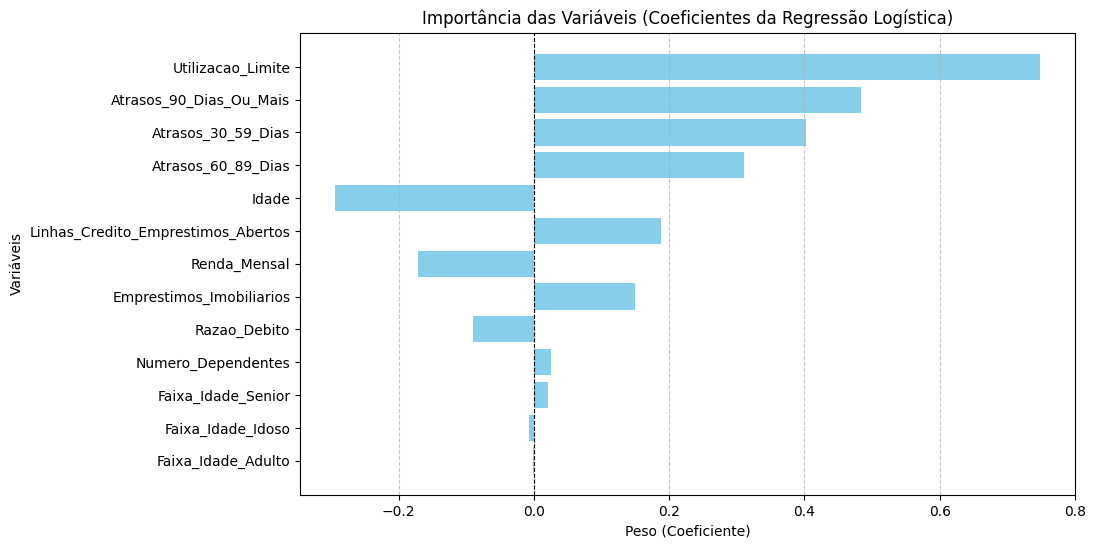

In [30]:
import numpy as np

# 1. Extrair os coeficientes e nomes das colunas
# Se estiver usando Pipeline: modelo_final_tunado.named_steps['logistic'].coef_
coeficientes = modelo_final_tunado.named_steps['logistic'].coef_[0]
features = X_completo.columns

# 2. Criar um DataFrame para facilitar a visualização
importancia_df = pd.DataFrame({'Feature': features, 'Coeficiente': coeficientes})
importancia_df['Abs_Coeficiente'] = importancia_df['Coeficiente'].abs()
importancia_df = importancia_df.sort_values(by='Abs_Coeficiente', ascending=True)

# 3. Plotar
plt.figure(figsize=(10, 6))
plt.barh(importancia_df['Feature'], importancia_df['Coeficiente'], color='skyblue')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Importância das Variáveis (Coeficientes da Regressão Logística)')
plt.xlabel('Peso (Coeficiente)')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()